#Transfer Learning

🧠 What is Transfer Learning?

Transfer learning means taking a pre-trained model (one that has already learned from a large dataset) and reusing it for a new but related task — instead of training a model from scratch.

Example: Medical image analysis

⚙️ How It Works

Start with a pre-trained model (like ResNet, VGG, or BERT).

Freeze most of its layers (keep existing learned features).

Replace the final layer(s) with new ones suited to your target task.

Train (fine-tune) on your dataset.

In [ ]:
import tensorflow as tf

In [ ]:
import matplotlib.pylab as plt

import tensorflow_hub as hub
import tensorflow_datasets as tfds

from tensorflow.keras import layers

In [ ]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

Use a TensorFlow Hub MobileNet for prediction

In [ ]:
CLASSIFIER_URL ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/2"
IMAGE_RES = 224

class MyModel(tf.keras.Model):
  def __init__(self, classifier_url, image_res):
    super(MyModel, self).__init__()
    self.classifier = hub.KerasLayer(classifier_url, input_shape=(image_res, image_res, 3))

  def call(self, inputs):
    return self.classifier(inputs)

model = MyModel(CLASSIFIER_URL, IMAGE_RES)

61306/61306 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


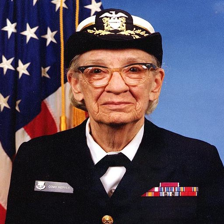

In [ ]:
import numpy as np
import PIL.Image as Image

grace_hopper = tf.keras.utils.get_file('image.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg')
grace_hopper = Image.open(grace_hopper).resize((IMAGE_RES, IMAGE_RES))
grace_hopper

In [ ]:
grace_hopper = np.array(grace_hopper)/255.0
grace_hopper.shape

(224, 224, 3)

In [ ]:
result = model.predict(grace_hopper[np.newaxis, ...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


(1, 1001)

In [ ]:
predicted_class = np.argmax(result[0], axis=-1)
predicted_class

np.int64(653)

10484/10484 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


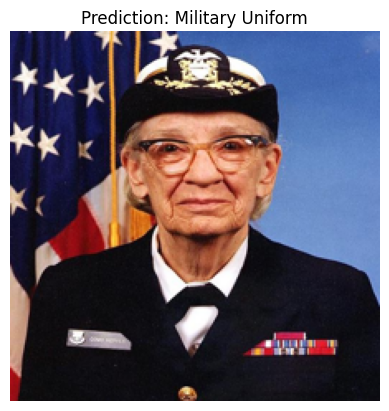

In [ ]:
labels_path = tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
imagenet_labels = np.array(open(labels_path).read().splitlines())

plt.imshow(grace_hopper)
plt.axis('off')
predicted_class_name = imagenet_labels[predicted_class]
_ = plt.title("Prediction: " + predicted_class_name.title())

In [ ]:
(train_examples, validation_examples), info = tfds.load(
    'cats_vs_dogs',
    with_info=True,
    as_supervised=True,
    split=['train[:80%]', 'train[80%:]'],
)

num_examples = info.splits['train'].num_examples
num_classes = info.features['label'].num_classes

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.1LDEG0_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
for i, example_image in enumerate(train_examples.take(3)):
  print("Image {} shape: {}".format(i+1, example_image[0].shape))

Image 1 shape: (262, 350, 3)
Image 2 shape: (409, 336, 3)
Image 3 shape: (493, 500, 3)


So we need to reformat all images to the resolution expected by MobileNet (224, 224).

In [ ]:
def format_image(image, label):
  image = tf.image.resize(image, (IMAGE_RES, IMAGE_RES))/255.0
  return image, label

BATCH_SIZE = 32

train_batches      = train_examples.shuffle(num_examples//4).map(format_image).batch(BATCH_SIZE).prefetch(1)
validation_batches = validation_examples.map(format_image).batch(BATCH_SIZE).prefetch(1)

In [ ]:
image_batch, label_batch = next(iter(train_batches.take(1)))
image_batch = image_batch.numpy()
label_batch = label_batch.numpy()

result_batch = model.predict(image_batch)

predicted_class_names = imagenet_labels[np.argmax(result_batch, axis=-1)]
predicted_class_names

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


array(['Persian cat', 'otterhound', 'tiger cat', 'Newfoundland',
       'Rottweiler', 'Labrador retriever', 'tabby',
       'Staffordshire bullterrier', 'Egyptian cat', 'Persian cat',
       'Egyptian cat', 'Italian greyhound', 'tabby', 'Egyptian cat',
       'Egyptian cat', 'Egyptian cat', 'tabby', 'Egyptian cat',
       'Persian cat', 'tabby', 'standard poodle', 'Siamese cat',
       'wire-haired fox terrier', 'Persian cat', 'briard', 'Persian cat',
       'dishwasher', 'tabby', 'Egyptian cat', 'mouse', 'Eskimo dog',
       'whippet'], dtype='<U30')

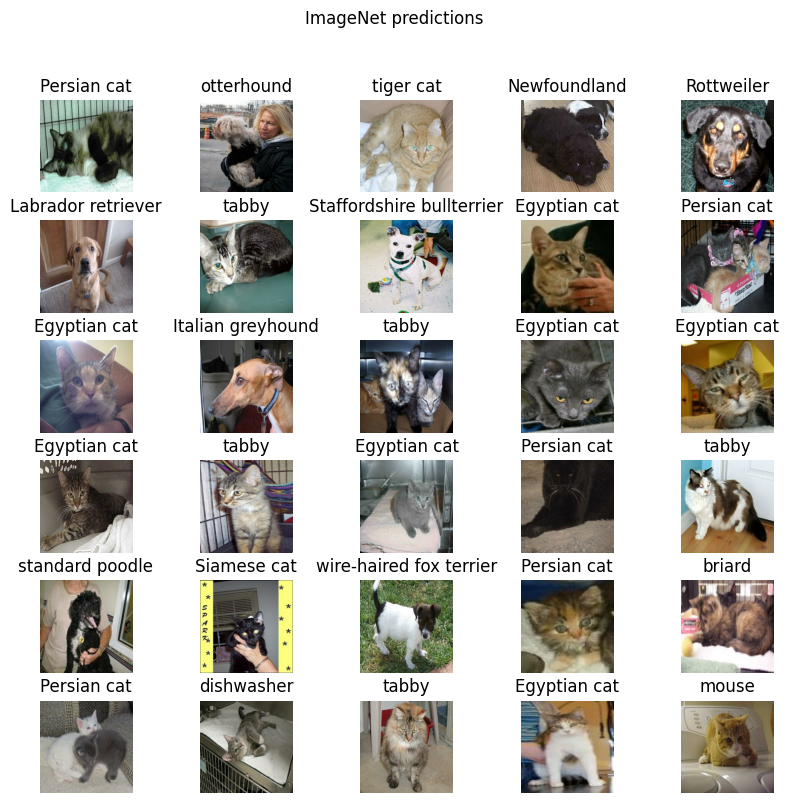

In [ ]:
plt.figure(figsize=(10,9))
for n in range(30):
  plt.subplot(6,5,n+1)
  plt.subplots_adjust(hspace = 0.3)
  plt.imshow(image_batch[n])
  plt.title(predicted_class_names[n])
  plt.axis('off')
_ = plt.suptitle("ImageNet predictions")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load pretrained MobileNetV2 (without the top layer)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,   # remove default classification head
    weights='imagenet'   # use pretrained weights
)

# 2. Freeze the base model (we don't train these layers)
base_model.trainable = False

# 3. Build a Sequential model
model = models.Sequential([
    base_model,                            # pretrained feature extractor
    layers.GlobalAveragePooling2D(),       # reduce dimensions
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification (cat vs dog)
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 6
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches)

Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


582/582 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.5093 - loss: nan - val_accuracy: 0.4901 - val_loss: nan
Epoch 2/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5088 - loss: nan - val_accuracy: 0.4901 - val_loss: nan
Epoch 3/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5113 - loss: nan - val_accuracy: 0.4901 - val_loss: nan
Epoch 4/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5101 - loss: nan - val_accuracy: 0.4901 - val_loss: nan
Epoch 5/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.5094 - loss: nan - val_accuracy: 0.4901 - val_loss: nan
Epoch 6/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.5080 - loss: nan - val_accuracy: 0.4901 - val_loss: nan


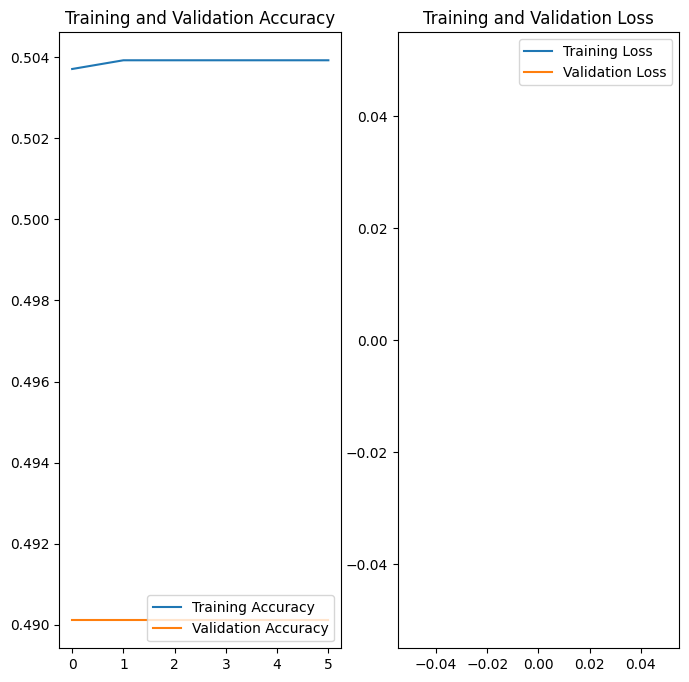

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# EfficientNetB0

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)
base_model.trainable = False  # freeze pretrained layers

In [ ]:
# Build model
model = models.Sequential([
    layers.Rescaling(1./255 , input_shape=(224, 224, 3)),          # simple scaling instead of preprocess_input
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 6
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches)


Epoch 1/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 94s 112ms/step - accuracy: 0.5040 - loss: 0.6957 - val_accuracy: 0.5099 - val_loss: 0.7003
Epoch 2/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.4962 - loss: 0.6956 - val_accuracy: 0.4901 - val_loss: 0.6986
Epoch 3/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 72ms/step - accuracy: 0.5063 - loss: 0.6949 - val_accuracy: 0.4901 - val_loss: 0.6959
Epoch 4/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 62ms/step - accuracy: 0.5045 - loss: 0.6949 - val_accuracy: 0.4901 - val_loss: 0.6961
Epoch 5/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.4913 - loss: 0.6956 - val_accuracy: 0.5099 - val_loss: 0.7040
Epoch 6/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.4995 - loss: 0.6964 - val_accuracy: 0.4901 - val_loss: 0.6983


In [ ]:
from tensorflow.keras.applications import ResNet50V2, EfficientNetB0, VGG16

# base_model = ResNet50V2(include_top=False, input_shape=(224,224,3), weights='imagenet')
# OR
# base_model = EfficientNetB0(include_top=False, input_shape=(224,224,3), weights='imagenet')
# OR
base_model = VGG16(include_top=False, input_shape=(224,224,3), weights='imagenet')


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False  # freeze pretrained layers

In [ ]:
# Build model
model = models.Sequential([
    layers.Rescaling(1./255 , input_shape=(224, 224, 3)),          # simple scaling instead of preprocess_input
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,790,721 (56.42 MB)

 Trainable params: 76,033 (297.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
EPOCHS = 6
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches)


Epoch 1/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 154s 225ms/step - accuracy: 0.5003 - loss: 0.6944 - val_accuracy: 0.4901 - val_loss: 0.6933
Epoch 2/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 122s 198ms/step - accuracy: 0.5036 - loss: 0.6937 - val_accuracy: 0.5099 - val_loss: 0.6930
Epoch 3/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 122s 198ms/step - accuracy: 0.4987 - loss: 0.6939 - val_accuracy: 0.5099 - val_loss: 0.6930
Epoch 4/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 122s 198ms/step - accuracy: 0.4986 - loss: 0.6936 - val_accuracy: 0.5099 - val_loss: 0.6931
Epoch 5/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 120s 198ms/step - accuracy: 0.5117 - loss: 0.6932 - val_accuracy: 0.5099 - val_loss: 0.6929
Epoch 6/6
582/582 ━━━━━━━━━━━━━━━━━━━━ 120s 198ms/step - accuracy: 0.5079 - loss: 0.6934 - val_accuracy: 0.5099 - val_loss: 0.6930
